# Interactive Plotting

Interactively plot target_phot, comp_phot, and inspect_nights.

Author: Qiushi Chris Tian

Created: 2026-09-28

Updated: 

## Interactive Setting

Requires `ipyml`. Enable with either `%matplotlib ipympl` or `%matplotlib widget`.

In [2]:
%matplotlib ipympl

## Imports and Style

In [1]:
from pathlib import Path
from astropy import table
import numpy as np
import json
from datetime import datetime

from dep import plt, va

from optimize_rel_phot import RelativePhotometryEngine, plot_target
from newport import TARGET_GAIA_DR3, get_excluded_comp, get_input_path

In [ ]:
plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["serif"]

In [ ]:
plt.rcParams["font.sans-serif"]

In [ ]:
plt.style.use('stix')

In [ ]:
plt.style.available

## `target_phot.py`

### Constants/Preamble

In [3]:
TARGET = 'TOI-431'
TARGET_ID = TARGET_GAIA_DR3[TARGET]

OVERWRITE = False

PRINT_COMP = False

RUN_PHOT = False
# RUN_PHOT = True

TMIN = None
TMAX = None # datetime(2024, 4, 15)

FORCE_COMP = False

# FORCE_COMP = True
# FORCED_COMPS = [
#     "1958536599157070592",
#     "1958537561228353152",
#     "1958561200728431872",
#     "1958588860317508224",
#     "1958608720246495360"
# ]
# REF_COMPS = [
#     "1958536599157070592",
#     "1958537561228353152",
#     "1958561200728431872",
#     "1958582671266686080",
#     "1958583603279110528",
#     "1958586867452688768",
#     "1958588860317508224",
#     "1958608720246495360"
# ]

if FORCE_COMP:
    CRIT = np.nan
    OUTPUT_DIR = Path(
        f'data/tables/opt_comp_stars/{TARGET}/man_del3_c5'
    )
else:
    CRIT = 0.9
    OUTPUT_DIR = Path(
        f'data/tables/opt_comp_stars/{TARGET}/'
        f'crit{str(CRIT).replace("0.", "")}'
    )
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
COMP_DIAG_DIR = OUTPUT_DIR / 'comp_diag'

### Main

In [4]:
print(f'Newport photometry for target {TARGET} to {OUTPUT_DIR}')

full_table = table.Table.read(get_input_path(TARGET))

Newport photometry for target TOI-431 to data/tables/opt_comp_stars/TOI-431/crit9


#### BLOCK: Print out comparison stars for comp diag

In [ ]:
if PRINT_COMP:
    COMP_DIAG_DIR.mkdir(parents=True, exist_ok=True)

    comp_set = set()
    for band in ['B', 'V', 'R', 'I']:
        json_path = OUTPUT_DIR / f"comps_{band}.json"
        comp_set.update(load_from_json(json_path, ['forced_comps', 'best_ensemble']))

    for cid in comp_set:
        print(f"Gaia DR3 {cid}:")
        for band in ['B', 'V', 'R', 'I']:
            t = table.Table.read(COMP_DIAG_DIR / f"bin_diag_{cid}_{band}.fits")
            e = t.meta['COMPIDS']
            print(f"  {band}: {e}")

#### BLOCK: Run ensembles

HST visit report time: Sun Feb 15 23:07:52 EST 2026
B	52	541
V	47	577
R	54	1129
I	51	1059
this is wfc3_line: []
this is stis_line: []
Either or both `wfc3_line` or `stis_line` is empty. Not plotting HST legend.


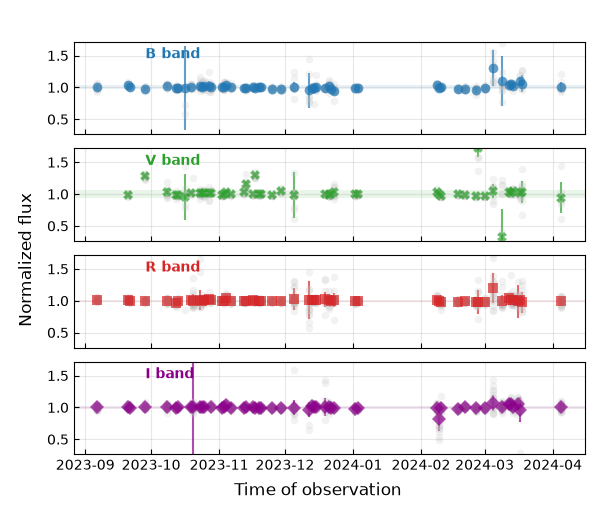

In [5]:
read_saved_table_base = OUTPUT_DIR / "results"

if RUN_PHOT:
    bands = ['B', 'V', 'R', 'I']  # np.unique(full_table['band'])
    all_binned = []
    all_unbinned = []

    for i, band in enumerate(bands):
        print(f"\n--- Band {band} ---")
        band_table = full_table[full_table['band'] == band]

        # Only 766452769615859712 has no V band data
        if len(band_table) == 0:
            print(f"No data for band {band}. Skipping.")
            continue
        
        # 1. Optimize (or use forced comps)
        if FORCE_COMP:
            best_ensemble = FORCED_COMPS
        else:
            best_ensemble, all_comps = get_comps(
                band_table, TARGET_ID, criterion=CRIT,
                exclude_ids=get_excluded_comp(TARGET, band)
            )
        
        # 2. Save results (includes binned/unbinned + metadata)
        engine = RelativePhotometryEngine(band_table, TARGET_ID)
        output_fn_base = OUTPUT_DIR / f"results_{band}"
        engine.save(best_ensemble, output_fn_base, sig_clip=3, overwrite=OVERWRITE)
        
        # Collect for stacking
        bin_t = table.Table.read(OUTPUT_DIR / f"bin_results_{band}.fits")
        unbin_t = table.Table.read(OUTPUT_DIR / f"unbin_results_{band}.fits")
        bin_t['band'] = band
        unbin_t['band'] = band
        all_binned.append(bin_t)
        all_unbinned.append(unbin_t)

        # 3. Save optimization summary
        summary = {
            "target": TARGET,
            "target_id": TARGET_ID,
            "band": band, 
        }

        if FORCE_COMP:
            summary.update({
                "forced_comps": FORCED_COMPS,
                "ref_comps": REF_COMPS,
            })
        else:
            summary.update({
                "best_ensemble": best_ensemble,
                "all_comps": all_comps,
            })
        
        output_json = OUTPUT_DIR / f"comps_{band}.json"
        with open(output_json, "w") as f:
            json.dump(summary, f, indent=4)
        print(f"Summary saved to {output_json}")
        print(best_ensemble)

    # 4. Save consolidated tables
    if all_binned:
        table.vstack(all_binned).write(OUTPUT_DIR / "bin_results_all.fits", overwrite=OVERWRITE)
        table.vstack(all_unbinned).write(OUTPUT_DIR / "unbin_results_all.fits", overwrite=OVERWRITE)
        print(f"\nConsolidated results saved to {OUTPUT_DIR}/[bin|unbin]_results_all.fits")

# 5. Multi-band plot from saved tables
plot_target(
    read_saved_table_base,
    TARGET,
    # yrange=50,  # normally 12
    yrange='full',
    sharey=True,
    tmin=TMIN,
    tmax=TMAX,
    x_title=0.14,
    y_title=0.94,
    fig_width=6,
    fig_height_per_panel=1.3,
    sp_adj_top=0.92,
    # savefig_path=OUTPUT_DIR / f"photometric_monitoring_{TARGET}.pdf"
)

## `inspect_nights.py`

Flagged 15 nights:
['20231015', '20231019', '20231022', '20231204', '20231211', '20231218', '20231222', '20240208', '20240226', '20240304', '20240308', '20240315', '20240316', '20240317', '20240404']


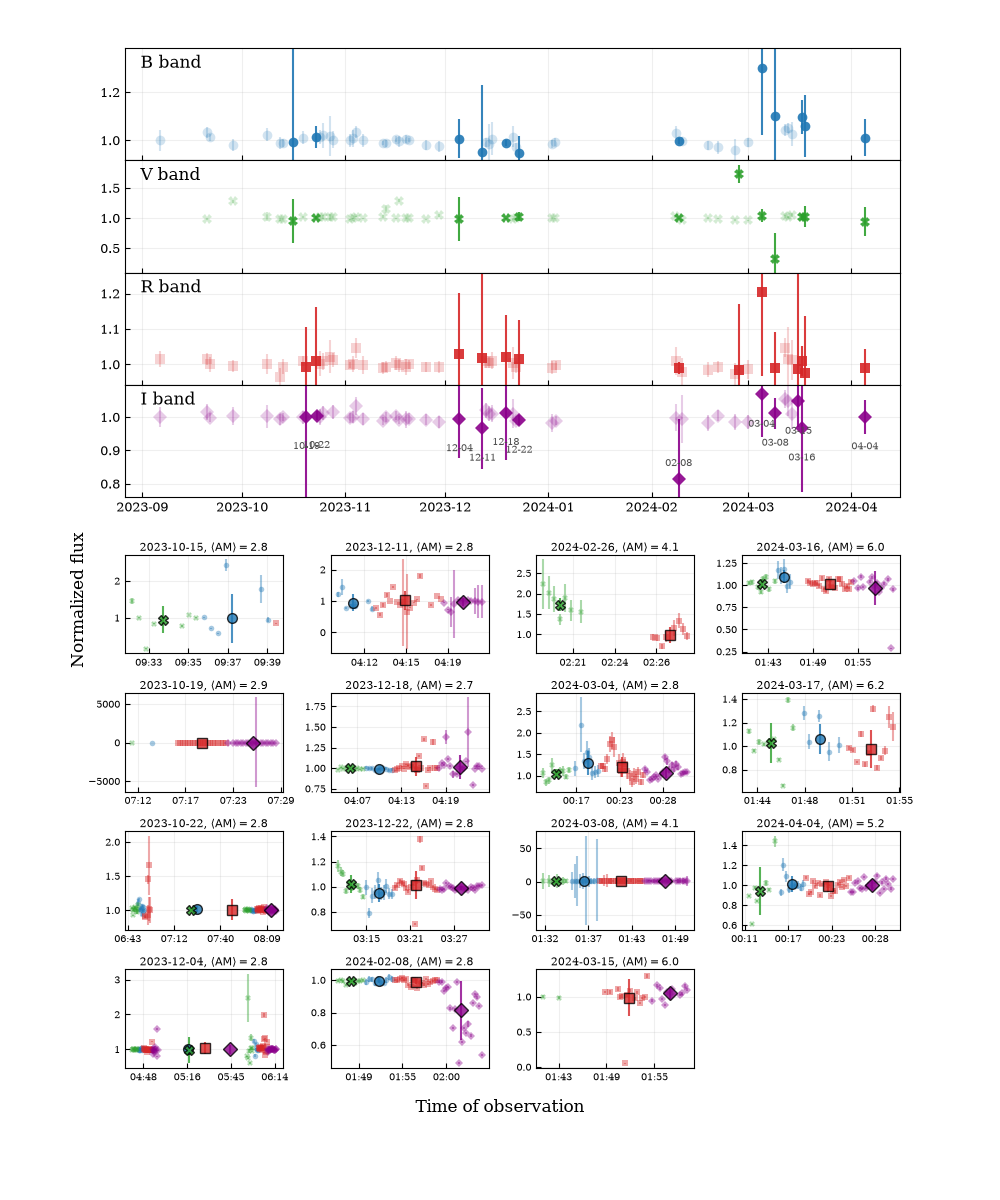

In [3]:
%run inspect_nights.py

## Utility: Table Inspection

In [5]:
t = unbin_tables['I']  # Naming used in inspection_nights.py

In [6]:
t[t['night'] == 20231019]

night,jd,airmass,exptime,flux,error
int32,float64,float64,float64,float64,float64
20231019,2460237.8080127314,2.90227007849,5.0,0.948143164888081,0.04167307044215949
20231019,2460237.807585301,2.90658579678,5.0,1.0167401026526106,0.06579992760553963
20231019,2460237.8111752314,2.87168026703,5.0,0.9012432273524323,0.018212460812017394
20231019,2460237.8084337963,2.89803882639,5.0,1.0339348658364411,0.050412753474543825
20231019,2460237.8088547452,2.89385075626,5.0,1.0554556621677877,0.0523966212793484
20231019,2460237.8113887734,2.86973732083,5.0,0.9879187351181109,0.018186579178356383
20231019,2460237.808645023,2.89594490624,5.0,1.0639907942590006,0.05453903127388693
20231019,2460237.811598611,2.86781808519,5.0,1.0917698718314996,0.0238121782928656
20231019,2460237.808219676,2.9001589315,5.0,0.9988613341434818,0.05087465314390315
